# Neflix Movies & TV Shows Dataset - Exploratory Data Analysis

#### This analysis explores patterns in Netlix content, including genres, release years, directors, ratings and regional distribution
#### The goal is to understand content trends and answer key insights such as the most common genres, top countries, and how Netflix has grown over time.

In [40]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")   # Ignore warnings


## 1. Load Dataset

We start by importing the dataset and checking the basic structure to understand what columns we will be working with.

In [41]:
# Load Dataset

df = pd.read_csv(r"dataset\netflix_show.csv")

In [42]:
# Preview

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 2. Initial Data Exploration

We check the dataset shape, data types, missing values, and summary statistics.

In [43]:
## Understand the data

#Basic info
df.info()

# Check for missing values
print(df.isnull().sum())

#Check Summary stats
print(df.describe(include='all'))

# Dataset Shape
df.shape 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0


(8807, 12)

### 📝 Insights:
- The dataset contains 8,807 rows and 12 columns.
- `director` and `cast` have the highest number of missing values.
- Numerical features like `show_id` do not contain missing values.
- The dataset contains both movies and TV shows.

## Data Cleaning

We handle missing values, standardize text columns, convert dates, and prepare the dataset for analysis.
💻 Code (cleaning):

In [44]:
# Standardize columns & Strip Strings

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype(str).str.strip().replace({'nan': np.nan})

In [45]:
# Date Parsing

df['date_added'] = df['date_added'].replace('nan', np.nan).astype('string').str.strip()
df['date_added'] =pd.to_datetime(df['date_added'],errors ='coerce', infer_datetime_format=True)


#Extract year, month & Day
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_added'] = df['date_added'].dt.day

#safe fallback if parsing failed -> keep release_year only
df['year_added'].isna().sum()

np.int64(10)

In [46]:
# release year sanity & duplicates

df['release_year'] =pd.to_numeric(df['release_year'], errors= 'coerce')
print("Min/Max Release Year:", df['release_year'].min(), df['release_year'].max())

#drop exact duplicate rows (if any)

before=len(df)
df.drop_duplicates(inplace=True)
after= len(df)
print(f"Dropped {before-after} duplicate rows")

Min/Max Release Year: 1925 2021
Dropped 0 duplicate rows


In [47]:
# Genres: Primary Genre + explode genre series

# genres: Create primary genre and explode genre series of analysis
# listed_in contains comma-separated genre

df['listed_in'] = df['listed_in'].replace('nan',np.nan)
df['genre_list'] =df['listed_in'].dropna().str.split(',').apply(lambda X: [g.strip() for g in X] if isinstance(X, list) else [])

#primary genre = first in the list or NaN
df['primary_genre'] =df['genre_list'].apply(lambda X: X[0] if isinstance(X, list) and len(X)> 0 else np.nan)


#exploding series for counting
genre_series = df['genre_list'].explode().dropna().reset_index(drop=True)

In [48]:
# Country Parsing (top country, multi-country handling)

df['country'] = df['country'].replace('nan', np.nan)
df['country_list'] = df['country'].dropna().str.split(', ').apply(lambda x: [c.strip() for c in x] if isinstance(x, list) else [])
df['primary_country'] =df['country_list'].apply(lambda X: X[0] if isinstance(X, list) and len(X)> 0 else 'Unknown')


In [49]:
#Duration Parsing: Minutes for movies and tv shows

# duration: extract numeric minutes for Movies and seasons for Tv shows
def parse_duration(row):
    val= row.get('duration', '')
    t = row.get('type', '')
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    # e.g "90 min" or "3 Seasons" 
    if 'min' in val:
        try:
            return int (val.replace('min', '').strip())
        except:
            return np.nan
    if 'Season' in val or 'season' in val:
        try: 
            return int(val.split()[0])
        except:
            return np.nan

    #fallback: extract any integer
    nums= ''.join(ch if (ch.isdigit() or ch==' ') else ' ' for ch in val).split()
    return int(nums[0]) if nums else np.nan

df['duration_parsed'] =df.apply(parse_duration, axis=1)

# Create separate numeric columns
df['duration_minutes'] = df.apply(lambda r: r['duration_parsed'] if r['type'].lower()=='movie' else np.nan, axis=1)
df['seasons'] = df.apply(lambda r: r['duration_parsed'] if r['type'].lower()!='movie' else np.nan, axis=1)


In [50]:
# Clean cast/director and create counts


# I. cast & director cleaning + counts
df['cast'] = df['cast'].replace('nan', np.nan)
df['director'] = df['director'].replace('nan', np.nan)

# create number of cast members
df['cast_count'] = df['cast'].fillna('').apply(lambda x: len([c.strip() for c in x.split(',') if c.strip()])) 
df['director_count'] = df['director'].fillna('').apply(lambda x: len([d.strip() for d in x.split(',') if d.strip()]))

# create a simplified top_cast list column (first 3 names)
def top_n_people(text, n=3):
    if pd.isna(text): return []
    items = [t.strip() for t in text.split(',') if t.strip()]
    return items[:n]

df['top_cast'] = df['cast'].apply(lambda x: top_n_people(x, 3))

In [51]:
# Missing value overview after cleaning

missing= df.isnull().sum().sort_values(ascending=False)
missing[missing>0]

seasons             6131
duration_minutes    2679
director            2634
country              831
country_list         831
cast                 825
month_added           10
date_added            10
year_added            10
rating                 4
duration_parsed        3
duration               3
dtype: int64

In [52]:
# Save Cleaned CSV to working directory 

#df.to_csv('netflix_cleaned.csv', index=False)

## Visualizations


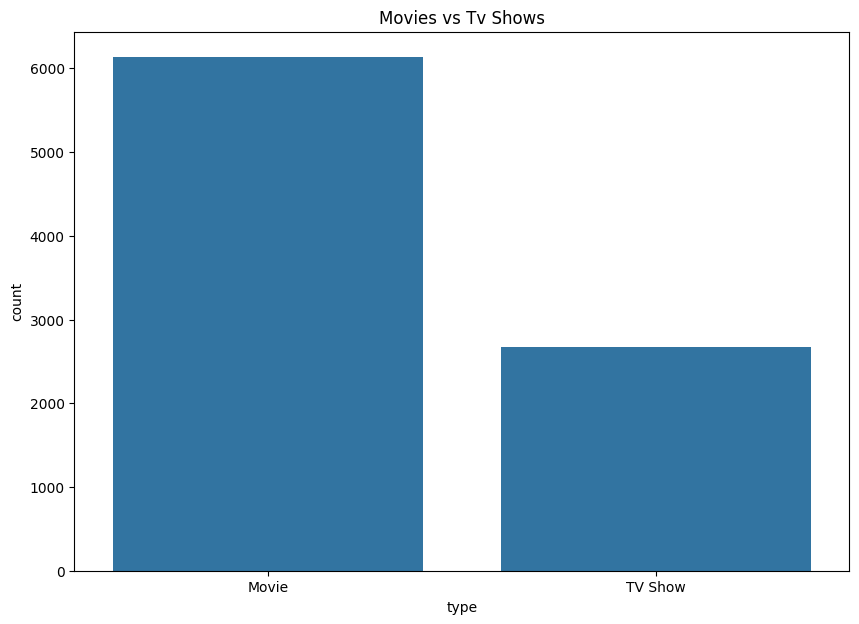

In [54]:
# Movies vs Tv Shows

plt.figure(figsize=(10,7))
sns.countplot(data=df, x=df['type'], order=df['type'].value_counts().index)
plt.title('Movies vs Tv Shows')
plt.show()



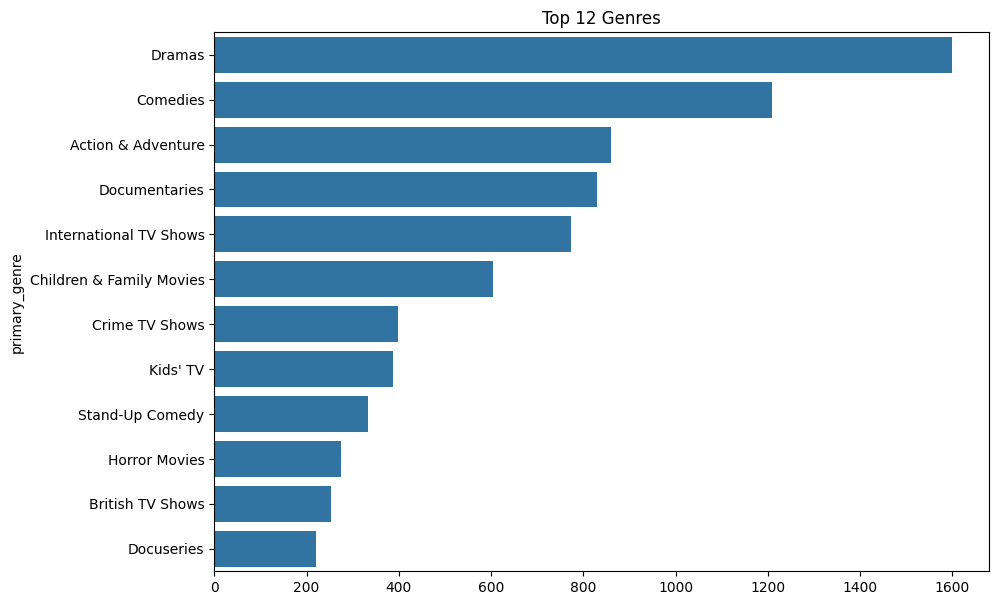

In [55]:
# Top 12 Primary Genres

plt.figure(figsize=(10,7))
top_primary =df['primary_genre'].value_counts().head(12)
sns.barplot(x=top_primary.values, y= top_primary.index)
plt.title('Top 12 Genres')
plt.show()


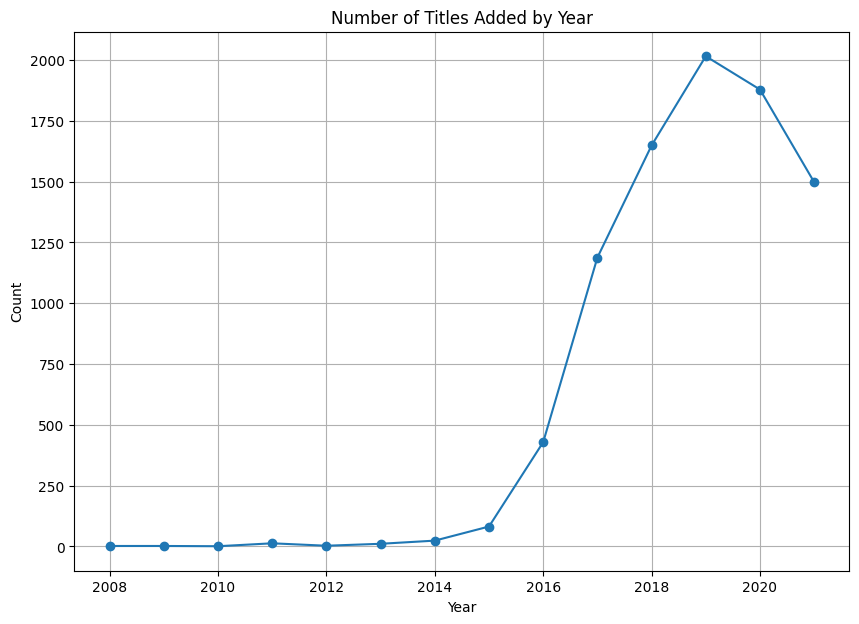

In [56]:
# Shows added by Year

plt.figure(figsize=(10,7))
year_counts =df['year_added'].value_counts().sort_index()
year_counts.plot(kind='line', marker='o')
plt.title('Number of Titles Added by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid(True)
plt.show()
    

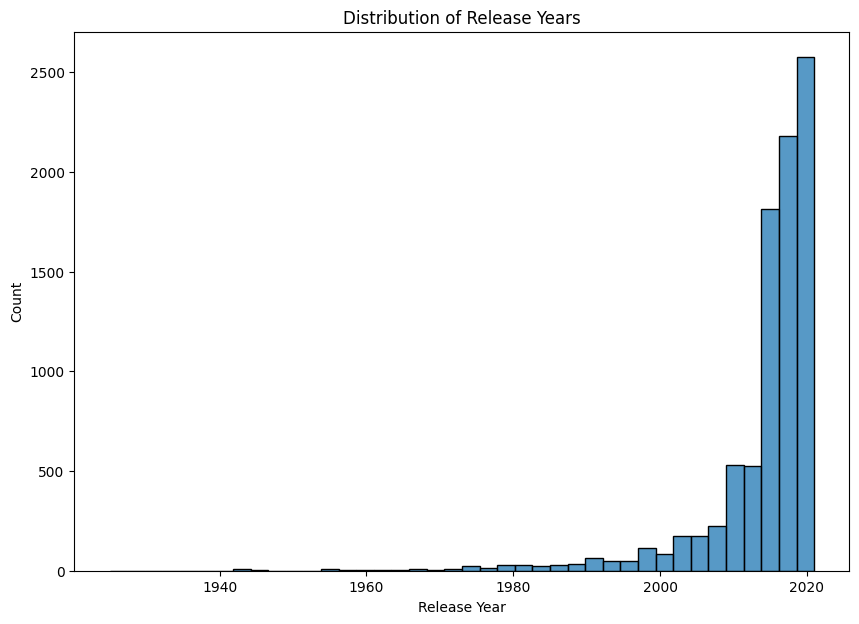

In [58]:
# Distribution of Release years

plt.figure(figsize=(10,7))
sns.histplot(df['release_year'].dropna(), bins=40, kde=False)
plt.title("Distribution of Release Years")
plt.xlabel('Release Year')
plt.show()

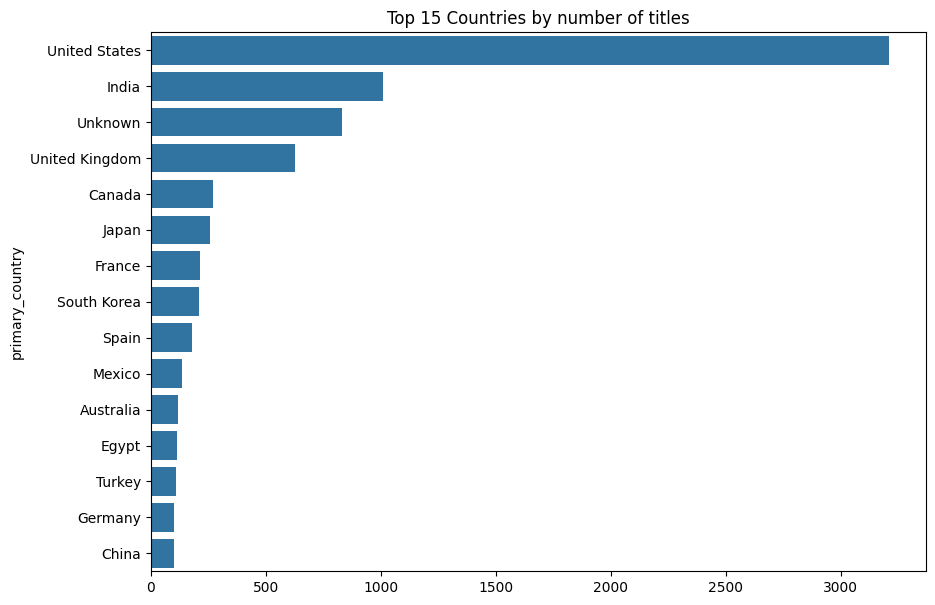

In [60]:
# Top Countries producing Titles

plt.figure(figsize=(10,7))
top_countries=df['primary_country'].value_counts().head(15)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 15 Countries by number of titles")
plt.show()



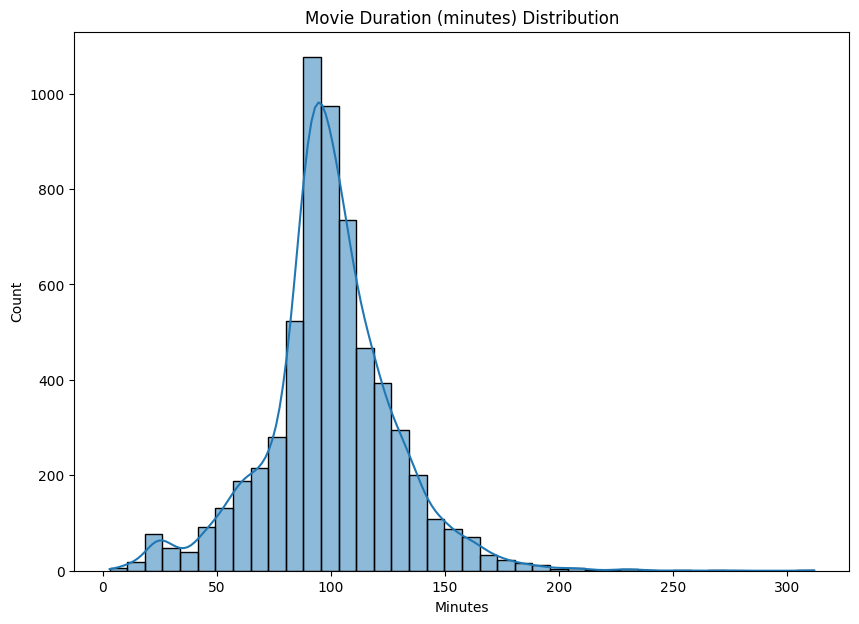

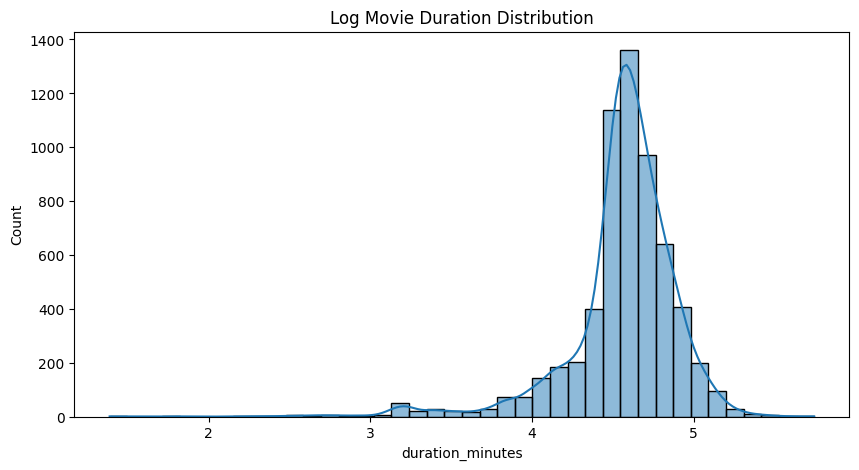

In [62]:
# Duration (movies) distribution & log scale

plt.figure(figsize=(10,7))
sns.histplot(df["duration_minutes"].dropna(), bins=40, kde=True)
plt.title("Movie Duration (minutes) Distribution")
plt.xlabel("Minutes")
plt.show()


# log scale to show long tail
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df['duration_minutes'].dropna()), bins=40, kde=True)
plt.title("Log Movie Duration Distribution")
plt.show()

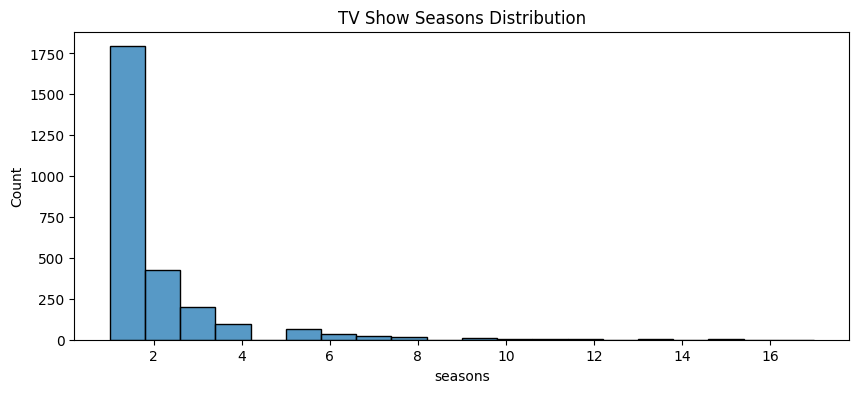

In [63]:
# Seasons Distribution (for Tv Shows)

plt.figure(figsize=(10,4))
sns.histplot(df['seasons'].dropna(), bins=20)
plt.title("TV Show Seasons Distribution")
plt.show()

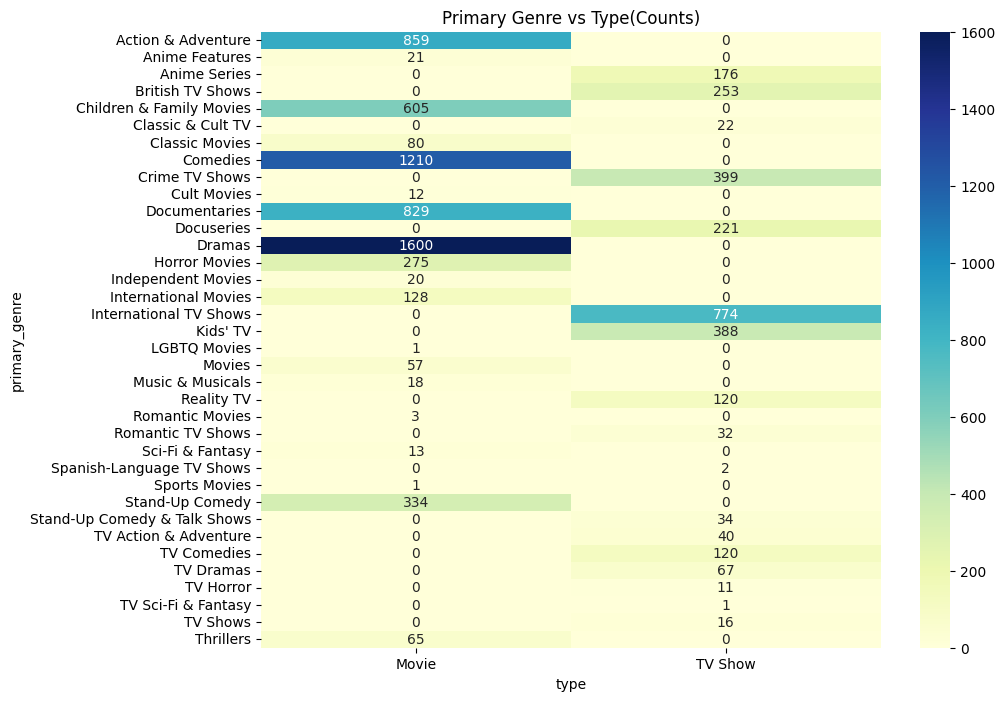

In [67]:
# Genre vs Type heatmap(counts)

pivot= pd.crosstab(df['primary_genre'], df['type'])
plt.figure(figsize=(10,8))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Primary Genre vs Type(Counts)")
plt.show()


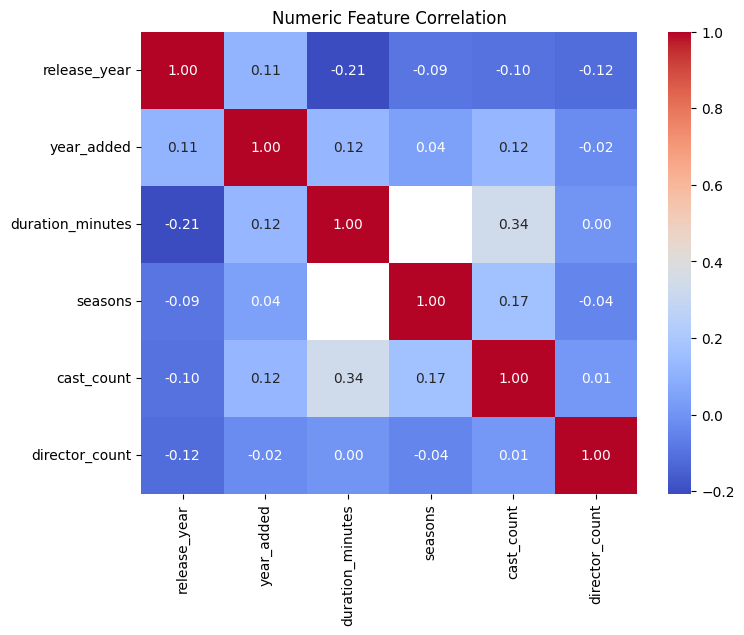

In [68]:
num = df[['release_year','year_added','duration_minutes','seasons','cast_count','director_count']].copy()
corr = num.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Numeric Feature Correlation")
plt.show()

# Conclusion

This analysis reveals the distribution of content across genres, directors, and countries.  
Netflix's content library has expanded significantly after 2015, with Movies being the dominant category.  
The dataset provides strong insights into content trends and platform strategy.
